In [ ]:
import pandas as pd
import bz2
import matplotlib.pyplot as plt

## Dataset Visualization


In [26]:
# load data
with bz2.open("crag_task_1_dev_v4_release.jsonl.bz2", "rt") as f:
    df = pd.read_json(f, lines=True)

C:\Users\likef\AppData\Local\Temp\ipykernel_16512\1164555561.py:3: FutureWarning: Parsed string "03/10/2024, 23:19:21 PT" included an un-recognized timezone "PT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df = pd.read_json(f, lines=True)
C:\Users\likef\AppData\Local\Temp\ipykernel_16512\1164555561.py:3: FutureWarning: Parsed string "03/13/2024, 10:19:56 PT" included an un-recognized timezone "PT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df = pd.read_json(f, lines=True)
C:\Users\likef\AppData\Local\Temp\ipykernel_16512\1164555561.py:3: FutureWarning: Parsed string "03/05/2024, 23:17:59 PT" included an un-recognized timezone "PT". Dropping unrecognized timezones is deprecated; in a future vers

In [27]:
print(f"Shape of the data: {df.shape}")

Shape of the data: (2706, 10)


In [28]:
print("Columns of the data:")
print(df.columns)

Columns of the data:
Index(['interaction_id', 'query_time', 'domain', 'question_type',
       'static_or_dynamic', 'query', 'answer', 'search_results', 'split',
       'alt_ans'],
      dtype='object')


In [29]:
print("First 5 rows of the data:")
df.head()

First 5 rows of the data:


,interaction_id,query_time,domain,question_type,static_or_dynamic,query,answer,search_results,split,alt_ans
0,7bb29eb4-12f9-45f9-bf8a-66832b3c8962,2024-03-10 23:19:21,sports,post-processing,static,how many 3-point attempts did steve nash avera...,4 3-points attempts per game,"[{'page_name': 'Steve Nash Stats, Height, Weig...",0,[]
1,a2486535-98e7-4876-9880-80374eac2fa8,2024-03-13 10:19:56,movie,simple_w_condition,static,what is a movie to feature a person who can cr...,a movie that features a person who can create ...,[{'page_name': 'Movies that feature physics co...,1,[]
2,161a89f3-7a70-4e12-a1a2-7832e098b0a7,2024-03-05 23:17:59,finance,multi-hop,slow-changing,where did the ceo of salesforce previously work?,"marc benioff spent 13 years at oracle, before ...",[{'page_name': 'The History of Salesforce - Sa...,1,[]
3,30395ec2-4247-4a23-8003-37dcfdf1531c,2024-03-19 23:50:41,movie,simple,static,which movie won the oscar best visual effects ...,tenet,[{'page_name': 'Final Oscars Predictions: Best...,1,[]
4,55b219e5-ba31-4318-a73d-551f0fb9c546,2024-03-05 23:18:31,finance,multi-hop,real-time,what company in the dow jones is the best perf...,salesforce,[{'page_name': '2024 Top Dow Jones Stocks | Th...,0,[]


Distribution of domain question types:


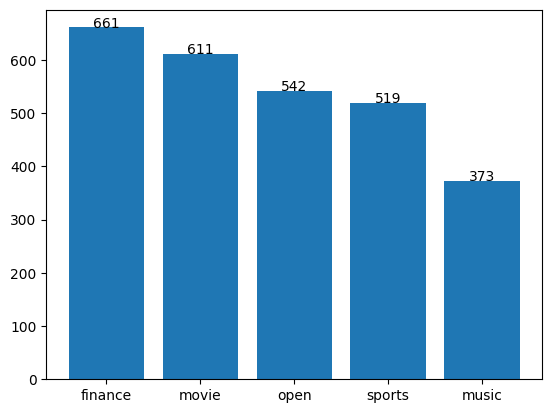

In [ ]:
print("Distribution of domain types:")
domains = df["domain"].value_counts()
plt.bar(domains.index, domains.values)
for i in range(len(domains)):
    plt.text(i, domains.values[i], domains.values[i], ha="center")

Distribution of dynamic types:


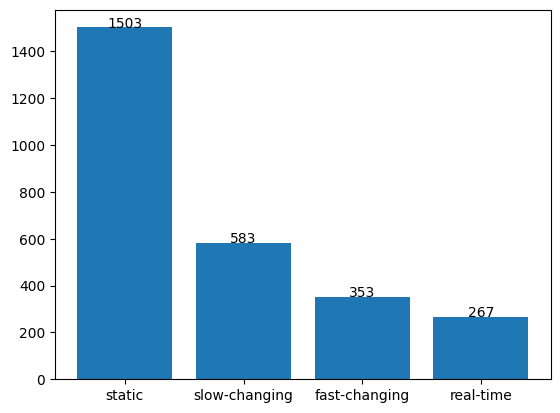

In [ ]:
print("Distribution of dynamic types:")
dynamics = df["static_or_dynamic"].value_counts()
plt.bar(dynamics.index, dynamics.values)
for i in range(len(dynamics)):
    plt.text(i, dynamics.values[i], dynamics.values[i], ha="center")

Distribution of question types:


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'simple'),
  Text(1, 0, 'simple_w_condition'),
  Text(2, 0, 'comparison'),
  Text(3, 0, 'aggregation'),
  Text(4, 0, 'false_premise'),
  Text(5, 0, 'set'),
  Text(6, 0, 'multi-hop'),
  Text(7, 0, 'post-processing')])

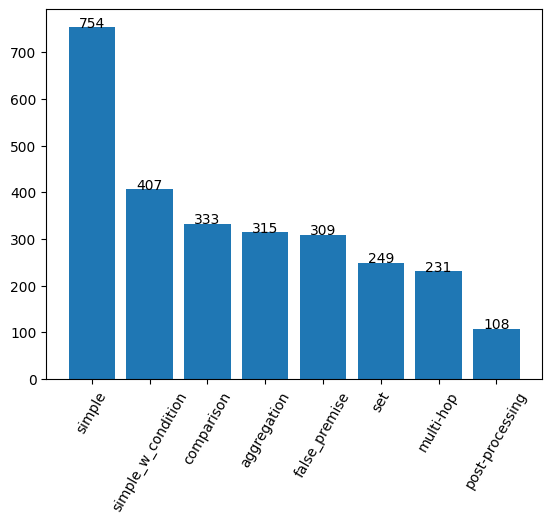

In [ ]:
print("Distribution of question types:")
question_types = df["question_type"].value_counts()
plt.bar(question_types.index, question_types.values)
for i in range(len(question_types)):
    plt.text(i, question_types.values[i], question_types.values[i], ha="center")
plt.xticks(rotation=60)

Distribution of question length:


Text(0, 0.5, 'Number of questions')

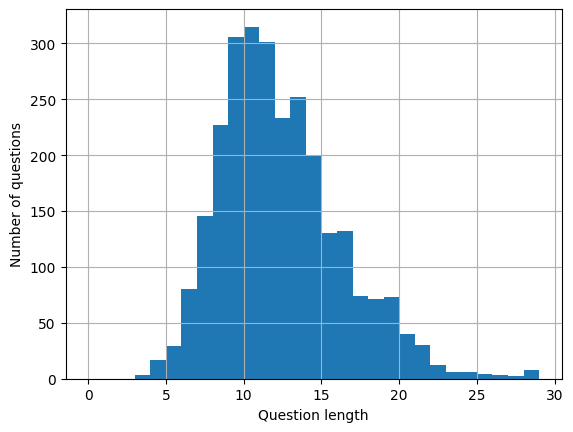

In [40]:
print("Distribution of question length:")
question_lengths = df["query"].apply(lambda x: len(x.split()))
question_lengths.hist(bins=range(0, 30))
plt.xlabel("Question length")
plt.ylabel("Number of questions")


## Analyze false premise questions


In [ ]:
with open("llama3.3_70b_predictions_task1_milvus_bge.jsonl", "r") as f:
    result1_df = pd.read_json(f, lines=True)

with open("llama3.3_70b_predictions_task2_milvus_bge.jsonl", "r") as f:
    result2_df = pd.read_json(f, lines=True)

print("First 5 rows of the data:")
result1_df.head()

First 5 rows of the data:


,query,ground_truth,prediction
0,how many 3-point attempts did steve nash avera...,4 3-points attempts per game,I don't know
1,what is a movie to feature a person who can cr...,a movie that features a person who can create ...,I don't know
2,where did the ceo of salesforce previously work?,"marc benioff spent 13 years at oracle, before ...",I don't know
3,which movie won the oscar best visual effects ...,tenet,Tenet
4,what company in the dow jones is the best perf...,salesforce,I don't know


In [ ]:
# add the predictions to the original dataframe
df["prediction_task1"] = result1_df["prediction"]
df["prediction_task2"] = result2_df["prediction"]

In [59]:
df.head()

,interaction_id,query_time,domain,question_type,static_or_dynamic,query,answer,search_results,split,alt_ans,prediction_task1,prediction_task2
0,7bb29eb4-12f9-45f9-bf8a-66832b3c8962,2024-03-10 23:19:21,sports,post-processing,static,how many 3-point attempts did steve nash avera...,4 3-points attempts per game,"[{'page_name': 'Steve Nash Stats, Height, Weig...",0,[],I don't know,I don't know
1,a2486535-98e7-4876-9880-80374eac2fa8,2024-03-13 10:19:56,movie,simple_w_condition,static,what is a movie to feature a person who can cr...,a movie that features a person who can create ...,[{'page_name': 'Movies that feature physics co...,1,[],I don't know,I don't know
2,161a89f3-7a70-4e12-a1a2-7832e098b0a7,2024-03-05 23:17:59,finance,multi-hop,slow-changing,where did the ceo of salesforce previously work?,"marc benioff spent 13 years at oracle, before ...",[{'page_name': 'The History of Salesforce - Sa...,1,[],I don't know,I don't know
3,30395ec2-4247-4a23-8003-37dcfdf1531c,2024-03-19 23:50:41,movie,simple,static,which movie won the oscar best visual effects ...,tenet,[{'page_name': 'Final Oscars Predictions: Best...,1,[],Tenet,i don't know
4,55b219e5-ba31-4318-a73d-551f0fb9c546,2024-03-05 23:18:31,finance,multi-hop,real-time,what company in the dow jones is the best perf...,salesforce,[{'page_name': '2024 Top Dow Jones Stocks | Th...,0,[],I don't know,I don't know


For false premise questions, the prediction should be "i don't know"


In [60]:
# false premise question
counter1 = df[df["question_type"] == "false_premise"]["prediction_task1"].value_counts()
counter1

prediction_task1
I don't know                      173
invalid question                   79
0                                  17
Never                               5
No                                  4
Yes                                 3
Invalid question                    2
July 1969                           1
25                                  1
Red One                             1
Toshiko Takaezu: Worlds Within      1
$3,600                              1
8 years                             1
2018                                1
Lennon/McCartney                    1
Anna Faris                          1
3LW                                 1
2004                                1
$1.219 billion                      1
Spring 2024                         1
The Pink Friday 2 World Tour        1
Jack Lindley Kuhns                  1
Florence by Mills                   1
Stuart Sutcliffe                    1
Victoria Beckham                    1
1940                             

In [61]:
counter2 = df[df["question_type"] == "false_premise"]["prediction_task2"].value_counts()
counter2

prediction_task2
I don't know                      146
invalid question                  110
i don't know                       16
0                                   6
Never                               3
Milwaukee Bucks                     1
Toshiko Takaezu: Worlds Within      1
8 years                             1
Phoenix Suns                        1
Yes                                 1
Lennon/McCartney                    1
Red One                             1
No                                  1
Anna Faris                          1
3LW                                 1
Invalid question                    1
Rush Hour 4                         1
July 1969                           1
The Pink Friday 2 World Tour        1
$1.219 billion                      1
$3,600                              1
Spring 2024                         1
Jack Lindley Kuhns                  1
She didn't                          1
Florence by Mills                   1
7.17                             

In [63]:
print("Accuracy of false premise question in task 1:")
(counter1["I don't know"]) / counter1.sum()

Accuracy of false premise question in task 1:


0.5598705501618123

In [64]:
print("Accuracy of false premise question in task 2:")
(counter2["I don't know"] + counter2["i don't know"]) / counter2.sum()

Accuracy of false premise question in task 2:


0.5242718446601942